<a href="https://colab.research.google.com/github/Edykiran/engenharia-de-prompt-fundamentos/blob/main/Aula07.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

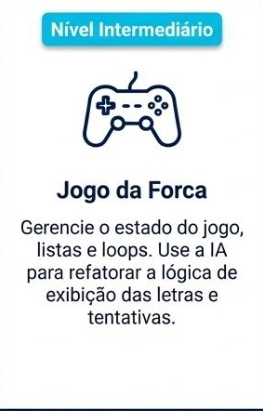

# Contexto:
Atue como um dev Python Sênior. Crie a Lógica de um joo da forca modular, separando a verificação de letras em uma função específica.


In [ ]:
import random

def choose_word():
    """Escolhe uma palavra aleatoriamente de uma lista predefinida."""
    words = ["python", "programacao", "desenvolvimento", "inteligencia", "artificial", "colaboracao"]
    return random.choice(words).upper()

def initialize_game(word):
    """Inicializa o estado do jogo (palavra secreta, letras adivinhadas, tentativas)."""
    return {
        "secret_word": word,
        "guessed_letters": set(),
        "incorrect_guesses": 0,
        "max_incorrect_guesses": 6,
        "display_word": ["_" for _ in word]
    }

def check_guess(guess, game_state):
    """Verifica a letra adivinhada e atualiza o estado do jogo."""
    secret_word = game_state["secret_word"]
    guessed_letters = game_state["guessed_letters"]
    incorrect_guesses = game_state["incorrect_guesses"]
    display_word = game_state["display_word"]

    guess = guess.upper()

    if guess in guessed_letters:
        print(f"Você já tentou a letra '{guess}'. Tente outra.")
        return False

    guessed_letters.add(guess)

    if guess in secret_word:
        print(f"Boa! A letra '{guess}' está na palavra.")
        for i, letter in enumerate(secret_word):
            if letter == guess:
                display_word[i] = guess
        return True
    else:
        print(f"Que pena! A letra '{guess}' não está na palavra.")
        game_state["incorrect_guesses"] += 1
        return False

def display_game_state(game_state):
    """Exibe o estado atual do jogo."""
    print("\n" + " ".join(game_state["display_word"]))
    print(f"Letras já tentadas: {', '.join(sorted(list(game_state['guessed_letters'])))}")
    print(f"Tentativas restantes: {game_state['max_incorrect_guesses'] - game_state['incorrect_guesses']}")
    print("---------------------")

def is_game_over(game_state):
    """Verifica se o jogo terminou (ganho ou perdido)."""
    if "_" not in game_state["display_word"]:
        print(f"Parabéns! Você adivinhou a palavra: {game_state['secret_word']}!")
        return True, "win"
    elif game_state["incorrect_guesses"] >= game_state["max_incorrect_guesses"]:
        print("\nGAME OVER!")
        print(f"Você ficou sem tentativas. A palavra era: {game_state['secret_word']}")
        return True, "lose"
    return False, "playing"

def play_hangman():
    """Função principal para jogar o jogo da forca."""
    print("Bem-vindo ao Jogo da Forca!")
    word_to_guess = choose_word()
    game_state = initialize_game(word_to_guess)

    while True:
        display_game_state(game_state)
        is_over, result = is_game_over(game_state)
        if is_over:
            break

        guess = input("Adivinhe uma letra: ").strip().upper()

        if not guess.isalpha() or len(guess) != 1:
            print("Entrada inválida. Por favor, digite apenas uma letra.")
            continue

        check_guess(guess, game_state)

# Para iniciar o jogo, chame a função play_hangman()
# play_hangman()

In [ ]:
play_hangman()

Bem-vindo ao Jogo da Forca!

_ _ _ _ _ _ _ _ _ _
Letras já tentadas: 
Tentativas restantes: 6
---------------------
Adivinhe uma letra: a
Boa! A letra 'A' está na palavra.

A _ _ _ _ _ _ _ A _
Letras já tentadas: A
Tentativas restantes: 6
---------------------
Adivinhe uma letra: c
Boa! A letra 'C' está na palavra.

A _ _ _ _ _ C _ A _
Letras já tentadas: A, C
Tentativas restantes: 6
---------------------
Adivinhe uma letra: e
Que pena! A letra 'E' não está na palavra.

A _ _ _ _ _ C _ A _
Letras já tentadas: A, C, E
Tentativas restantes: 5
---------------------
Adivinhe uma letra: d
Que pena! A letra 'D' não está na palavra.

A _ _ _ _ _ C _ A _
Letras já tentadas: A, C, D, E
Tentativas restantes: 4
---------------------
Adivinhe uma letra: i
Boa! A letra 'I' está na palavra.

A _ _ I _ I C I A _
Letras já tentadas: A, C, D, E, I
Tentativas restantes: 4
---------------------
Adivinhe uma letra: m
Que pena! A letra 'M' não está na palavra.

A _ _ I _ I C I A _
Letras já tentadas: A, C,

# Refatoração:
Refatore este loop while focado em performace. Evite mutação de estado desnecessária e comente as alterações.

In [ ]:
import random

def choose_word():
    """Escolhe uma palavra aleatoriamente de uma lista predefinida."""
    words = ["python", "programacao", "desenvolvimento", "inteligencia", "artificial", "colaboracao"]
    return random.choice(words).upper()

def initialize_game(word):
    """Inicializa o estado do jogo (palavra secreta, letras adivinhadas, tentativas)."""
    return {
        "secret_word": word,
        "guessed_letters": set(),
        "incorrect_guesses": 0,
        "max_incorrect_guesses": 6,
        "display_word": ["_" for _ in word]
    }

def check_guess(guess, current_game_state):
    """
    Verifica a letra adivinhada e retorna um *novo* estado do jogo.
    Esta função evita a mutação direta do dicionário `game_state` passado como argumento.
    Em vez disso, ela cria uma cópia do estado atual, aplica as modificações a essa cópia
    e retorna o novo estado. Isso torna o fluxo de dados mais previsível e explícito.
    """
    # Cria uma cópia profunda do estado atual para modificação,
    # evitando mutação direta do objeto 'current_game_state' original.
    new_game_state = {
        "secret_word": current_game_state["secret_word"],
        "guessed_letters": current_game_state["guessed_letters"].copy(), # Copia o set
        "incorrect_guesses": current_game_state["incorrect_guesses"],
        "max_incorrect_guesses": current_game_state["max_incorrect_guesses"],
        "display_word": list(current_game_state["display_word"]) # Copia a lista
    }

    guess = guess.upper()

    if guess in new_game_state["guessed_letters"]:
        print(f"Você já tentou a letra '{guess}'. Tente outra.")
        # Retorna o estado original se a letra já foi tentada, sem modificações.
        return current_game_state

    # Adiciona a letra ao conjunto copiado de letras adivinhadas.
    new_game_state["guessed_letters"].add(guess)

    if guess in new_game_state["secret_word"]:
        print(f"Boa! A letra '{guess}' está na palavra.")
        for i, letter in enumerate(new_game_state["secret_word"]):
            if letter == guess:
                # Atualiza a lista copiada de display_word.
                new_game_state["display_word"][i] = guess
        return new_game_state
    else:
        print(f"Que pena! A letra '{guess}' não está na palavra.")
        # Incrementa o contador de tentativas incorretas no estado copiado.
        new_game_state["incorrect_guesses"] += 1
        return new_game_state

def display_game_state(game_state):
    """Exibe o estado atual do jogo."""
    print("\n" + " ".join(game_state["display_word"]))
    print(f"Letras já tentadas: {', '.join(sorted(list(game_state['guessed_letters'])))}")
    print(f"Tentativas restantes: {game_state['max_incorrect_guesses'] - game_state['incorrect_guesses']}")
    print("---------------------")

def is_game_over(game_state):
    """Verifica se o jogo terminou (ganho ou perdido)."""
    if "_" not in game_state["display_word"]:
        print(f"Parabéns! Você adivinhou a palavra: {game_state['secret_word']}!")
        return True, "win"
    elif game_state["incorrect_guesses"] >= game_state["max_incorrect_guesses"]:
        print("\nGAME OVER!")
        print(f"Você ficou sem tentativas. A palavra era: {game_state['secret_word']}")
        return True, "lose"
    return False, "playing"

def play_hangman():
    """Função principal para jogar o jogo da forca."""
    print("Bem-vindo ao Jogo da Forca!")
    word_to_guess = choose_word()
    game_state = initialize_game(word_to_guess)

    while True:
        display_game_state(game_state)
        is_over, result = is_game_over(game_state)
        if is_over:
            break

        guess = input("Adivinhe uma letra: ").strip().upper()

        if not guess.isalpha() or len(guess) != 1:
            print("Entrada inválida. Por favor, digite apenas uma letra.")
            continue

        # O estado `game_state` é agora explicitamente atualizado a cada iteração.
        # A função `check_guess` retorna um novo dicionário de estado,
        # evitando mutações internas diretas do objeto original e promovendo clareza.
        game_state = check_guess(guess, game_state)

# Para iniciar o jogo, chame a função play_hangman()
# play_hangman()

In [ ]:
play_hangman()

Bem-vindo ao Jogo da Forca!

_ _ _ _ _ _
Letras já tentadas: 
Tentativas restantes: 6
---------------------
Adivinhe uma letra: a
Que pena! A letra 'A' não está na palavra.

_ _ _ _ _ _
Letras já tentadas: A
Tentativas restantes: 5
---------------------
Adivinhe uma letra: e
Que pena! A letra 'E' não está na palavra.

_ _ _ _ _ _
Letras já tentadas: A, E
Tentativas restantes: 4
---------------------
Adivinhe uma letra: i
Que pena! A letra 'I' não está na palavra.

_ _ _ _ _ _
Letras já tentadas: A, E, I
Tentativas restantes: 3
---------------------
Adivinhe uma letra: o
Boa! A letra 'O' está na palavra.

_ _ _ _ O _
Letras já tentadas: A, E, I, O
Tentativas restantes: 3
---------------------
Adivinhe uma letra: u
Que pena! A letra 'U' não está na palavra.

_ _ _ _ O _
Letras já tentadas: A, E, I, O, U
Tentativas restantes: 2
---------------------
Adivinhe uma letra: y
Boa! A letra 'Y' está na palavra.

_ Y _ _ O _
Letras já tentadas: A, E, I, O, U, Y
Tentativas restantes: 2
-----------

# Debugging:
Não foi preciso